# Market Segmentation


**Objectives** 

This notebook aims to group LGAs into based on adoption profiles. To this end, key drivers of DER adoption need to be identified and new metrics derived.  

**Key Outputs**

LGAs segmented into four groups based on
- GrowthSolar: Primary adoption velocity signal.
- GrowthBattery: Storage infrastructure pressure.
- PenSolar (latest year): Current saturation level.
- BSR (latest year): Storage conversion readiness. 
- CPDSolar (latest year): Intensity of existing load.
for both residential and business data. 

Data injected back into SQLite database for loading into Power BI. 

**Data** 

Data is initially taken from three sources (ABS,AEMO and geographical mapping) and processed into three fact tables. Each table is indexed by year and LGA. 
- Q_Main_Derr: Aggregate AEMO DER data by LGA and year then joining LGA via postcode.
- Q_Population_Agg: Population data including population, median age, income, education levels in long form. 
- Q_Business_Agg: Economic data table including counts for business sectors and business size in long form. 
More details can be found in the README.md file. 


In [199]:
import pandas as pd
import numpy as np
np.random.seed(42)
np.seterr(divide='ignore', over='ignore', invalid='ignore') # Ignore divide by 0 warnings


from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA


In [200]:
# ---  Load Processed Data --- #
processed_path = "../data/processed"

# Load Metrics Data 
res_metrics = pd.read_parquet(processed_path+"/resmetrics_data.parquet")
bus_metrics = pd.read_parquet(processed_path+"/busmetrics_data.parquet")

## EDA

In [201]:
res_metrics.columns

Index(['Year', 'Lga', 'PenTotal', 'CPDTotal', 'CPCTotal', 'GrowthTotal',
       'PenBattery', 'CPDBattery', 'CPCBattery', 'GrowthBattery', 'PenSolar',
       'CPDSolar', 'CPCSolar', 'GrowthSolar', 'PenOther', 'CPDOther',
       'CPCOther', 'GrowthOther', 'BSR'],
      dtype='str')

In [202]:
res_metrics_24 = res_metrics[res_metrics['Year']==res_metrics['Year'].max()]
bus_metrics_24 = bus_metrics[res_metrics['Year']==res_metrics['Year'].max()]

<Axes: xlabel='PenSolar', ylabel='GrowthSolar'>

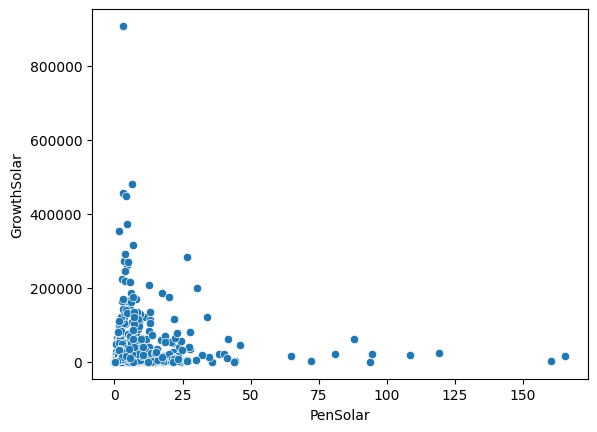

In [203]:
# Plot solar penetration and growth solar
sns.scatterplot(
    data=res_metrics_24,
    x='PenSolar',
    y='GrowthSolar'
    )
    


<Axes: xlabel='PenSolar', ylabel='GrowthSolar'>

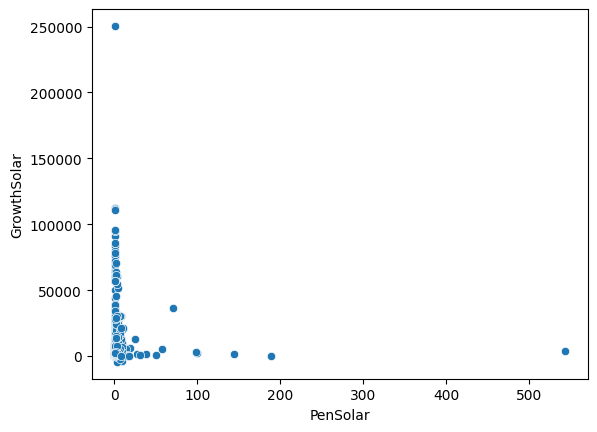

In [204]:
# Plot solar penetration and growth solar
sns.scatterplot(
    data=bus_metrics_24,
    x='PenSolar',
    y='GrowthSolar'
    )
    

## Clustering

We segment LGAs by two methods.

We first segment is based on 
- GrowthSolar: Primary adoption velocity signal,
- GrowthBattery: Storage infrastructure pressure,
- PenSolar (latest year): Current saturation level,
- BSR (latest year): Storage conversion readiness and 
- CPDSolar (latest year): Intensity of existing load.


### Number of Clusters

The elbow method is used to determine the optimal number of clusters. We plot the distortion of clusters against number of clusters.

In [205]:
# --- Define function to plot distortion of clusters --- #

def cluster_elbow(dataframe: pd.DataFrame, variable_list: list):
    
    # Prepare data
    df = dataframe[variable_list].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    X = StandardScaler().fit_transform(df.values)

    # Hyper parameter tuning using elbow method with distortion as a metric 

    k_groups = range(1,14)
    distortion = []

    for k in k_groups:
        # Fit Kmeans over number of groups
        kmeans = KMeans(n_clusters = k,random_state=42).fit(X)
        distortion.append(sum(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
        
    # Distortion plot 
    plt.plot(k_groups, distortion, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Distortion')
    plt.title('The Elbow Method using Distortion')
    plt.show()
    

The following plot shows the distortion for residential data. The cutoff before diminishing returns occurs after 4 clusters.  

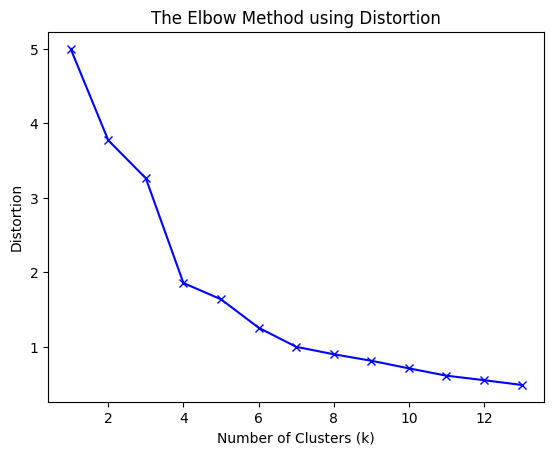

In [206]:
# --- Create distortion plot for residential data --- #

# Find optimal number of clusters for Kmeans
target_var_list = ['GrowthSolar',
                   'GrowthBattery',
                   'PenSolar',
                   'BSR',
                   'CPDSolar']

cluster_elbow(res_metrics_24,target_var_list)


The following plot shows the distortion for business data. The cutoff before diminishing returns occurs after 4 clusters.  

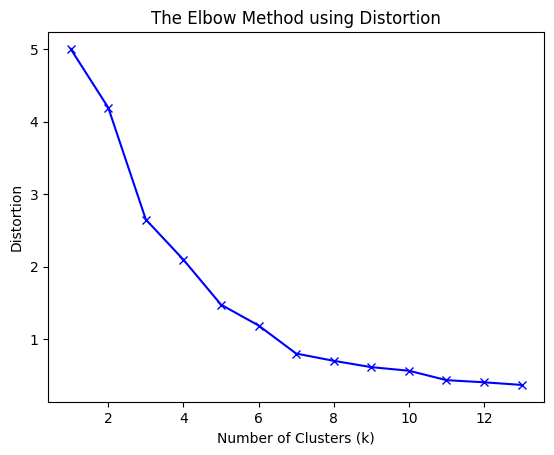

In [207]:
# --- Create distortion plot for business data --- #

# Find optimal number of clusters for Kmeans
target_var_list = ['GrowthSolar',
                   'GrowthBattery',
                   'PenSolar',
                   'BSR',
                   'CPDSolar']

cluster_elbow(bus_metrics_24,target_var_list)

In both cases, 4 clusters should be used.

### Fit and Diagnostics 

In [208]:
# --- Function to carry out clustering and PCA projection --- #

def clustering(dataframe: pd.DataFrame, variable_list:list, n_clusters: int):
    '''
    Standardises target columns on variable_list and applies Kmeans with n_clusters. 
    Returns a dataframe with a new column corresponding to the row's assigned cluster. 
    '''
    
    # Prepare data 
    df = dataframe[['Lga']+variable_list].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    
    
    X = df[df.columns[1:]].values
    X = StandardScaler().fit_transform(df[variable_list].values)

    print("Standardised data using standard scalar.")
    
    # Clustering Results
    kmeans = KMeans(n_clusters = n_clusters,random_state=42).fit(X)
    df['Cluster'] = kmeans.labels_ # Save to original dataframe
    
    # Save results
    clusters = df[['Lga','Cluster']]
 
    return clusters


def principal_components(dataframe: pd.DataFrame,
                         variable_list: list,
                         index_name: str,
                         pca_components: int):

    df = dataframe[[index_name] + variable_list].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    X = StandardScaler().fit_transform(df[variable_list].values)

    pca = PCA(n_components=pca_components)
    X_pca = pca.fit_transform(X)

    explained_var_ratio = pca.explained_variance_ratio_
    pca_vectors = pd.DataFrame(
        data=pca.components_,
        columns=variable_list
    )
    df_transformed = pd.DataFrame(
        data=X_pca,
        index=df[index_name].values,
        columns=[f'PC{i}' for i in range(1, pca_components + 1)]
    )

    return df_transformed, pca_vectors, explained_var_ratio


def plot_pca_clusters(df_transformed: pd.DataFrame,
                      clusters: pd.DataFrame,
                      explained_var_ratio: np.ndarray):
    """
    Plots LGA clusters projected onto PC1 vs PC2.
    
    df_transformed  : output of principal_components()
    clusters        : output of clustering()
    explained_var_ratio : output of principal_components()
    """

    df = df_transformed.copy()
    df['Cluster'] = clusters.set_index('Lga')['Cluster']
    df = df.dropna(subset=['Cluster'])

    fig, ax = plt.subplots(figsize=(5, 5))

    for cluster_id, group in df.groupby('Cluster'):
        ax.scatter(
            group['PC1'],
            group['PC2'],
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            edgecolors='k',
            linewidths=0.3
        )


    ax.legend(title='Cluster', markerscale=1.2)
    ax.set_xlabel(f'PC1 ({explained_var_ratio[0] * 100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({explained_var_ratio[1] * 100:.1f}% variance)')
    ax.set_title('LGA Clusters — PC1 vs PC2')
    plt.tight_layout()
    plt.show()


Standardised data using standard scalar.
Explained Variance Ratio: 0.9734241110895445


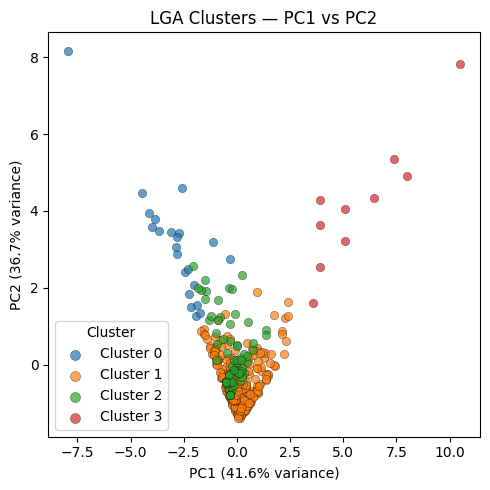

In [209]:
# --- Cluster and PCA Residential Data --- #

# List variables to standardise
target_var_list = ['GrowthSolar',
                   'GrowthBattery',
                   'PenSolar',
                   'BSR',
                   'CPDSolar']


# Apply clustering
res_clusters = clustering(res_metrics_24,target_var_list,4)

# Apply PCA 
res_pca, res_vecs , explained_var_ratio = principal_components(
                     dataframe = res_metrics_24,
                     variable_list= target_var_list,
                     index_name='Lga',
                     pca_components=3
                     )
print("Explained Variance Ratio:", str(sum(explained_var_ratio)))

# Plot clusters onto first two components 
plot_pca_clusters(res_pca, res_clusters, explained_var_ratio)


Standardised data using standard scalar.
Explained Variance Ratio: 0.8364141990528865


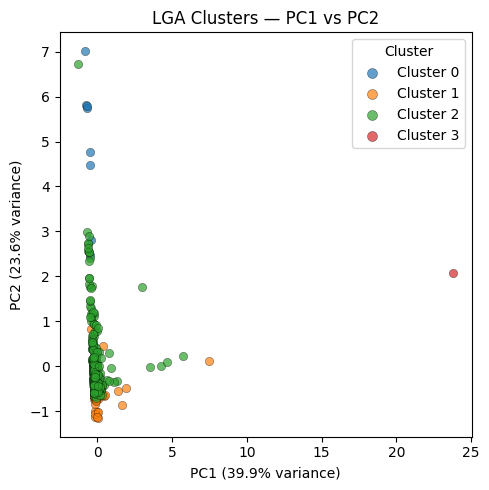

In [210]:
# --- Cluster and PCA Business Data --- #

# List variables to standardise
target_var_list = ['GrowthSolar',
                   'GrowthBattery',
                   'PenSolar',
                   'BSR',
                   'CPDSolar']


# Apply clustering 
bus_clusters = clustering(bus_metrics_24,target_var_list,4)

# Apply PCA to Business Data
bus_pca, bus_vecs , explained_var_ratio = principal_components(
                     dataframe = bus_metrics_24,
                     variable_list= target_var_list,
                     index_name='Lga',
                     pca_components=3
                     )

print("Explained Variance Ratio:",str(sum(explained_var_ratio)))

# Plot clusters onto first two components 
plot_pca_clusters(bus_pca, bus_clusters,explained_var_ratio)


### Cluster Interpretation

To assist with creating a meaningful description of these clusters we rank each group's mean score for across KPIs. These ranks are saved into the logs files as 'res_segment.txt' and 'bus_segment.txt'.

In [211]:
def interpret_clusters(clusters: pd.DataFrame,
                       der_df: pd.DataFrame,
                       der_vars: list,
                       output_path: str = '../logs/segments.txt') -> pd.DataFrame:
    """
    Projects cluster labels onto DER KPIs and returns per-cluster means with a descriptive label.
    
    Parameters:
    clusters : output of clustering() — columns ['Lga', 'Cluster']
    der_df   : dataframe containing DER KPIs with 'Lga' column
    der_vars : list of KPI column names to profile
    """

    df = der_df[['Lga'] + der_vars].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df['Cluster'] = df['Lga'].map(clusters.set_index('Lga')['Cluster'])
    df = df.dropna(subset=['Cluster'])

    # Cluster means
    means = df.groupby('Cluster')[der_vars].mean().round(3)

    # Rank clusters on each KPI 
    ranks = means.rank(ascending=True).astype(int)
    ranks.columns = [f'{c}_rank' for c in der_vars]

    # LGA count per cluster
    means['LGA_count'] = df.groupby('Cluster')['Lga'].count()

    output = (
            f"--- Cluster Means ---\n{means.to_string()}\n\n"
            f"--- Cluster Rankings (1 = lowest) ---\n{ranks.to_string()}"
        )

    print(output)

    with open(output_path, 'w') as f:
        f.write(output)
    print(f"\nSaved to {output_path}")

    return means, ranks

In [212]:
means, ranks = interpret_clusters(
    clusters = res_clusters,
    der_df   = res_metrics_24,
    der_vars = ['PenSolar', 'CPDSolar', 'BSR', 'GrowthSolar', 'GrowthBattery'],
    output_path= "../logs/res_segment.txt"
)


--- Cluster Means ---
         PenSolar  CPDSolar    BSR  GrowthSolar  GrowthBattery  LGA_count
Cluster                                                                  
0           7.997    44.733  0.061   278811.477      30366.285         22
1           8.716    46.156  0.022    41922.496       2392.200        281
2           9.501    51.927  0.085    28658.384       5405.648         68
3         104.764   559.054  0.041    18597.600       2614.536         10

--- Cluster Rankings (1 = lowest) ---
         PenSolar_rank  CPDSolar_rank  BSR_rank  GrowthSolar_rank  GrowthBattery_rank
Cluster                                                                              
0                    1              1         3                 4                   4
1                    2              2         1                 3                   1
2                    3              3         4                 2                   3
3                    4              4         2                 1

In [213]:
means, ranks = interpret_clusters(
    clusters = bus_clusters,
    der_df   = bus_metrics_24,
    der_vars = ['PenSolar', 'CPDSolar', 'BSR', 'GrowthSolar', 'GrowthBattery'],
    output_path= "../logs/bus_segment.txt"
)


--- Cluster Means ---
         PenSolar  CPDSolar    BSR  GrowthSolar  GrowthBattery  LGA_count
Cluster                                                                  
0.0         1.790    37.577  0.018    35660.920     170154.935          8
1.0         7.177   122.873  0.041     5980.440       1863.373         77
2.0         4.534    93.902  0.012    16619.006       2955.021        291
3.0       544.000  8743.100  0.019     3522.960         93.200          1

--- Cluster Rankings (1 = lowest) ---
         PenSolar_rank  CPDSolar_rank  BSR_rank  GrowthSolar_rank  GrowthBattery_rank
Cluster                                                                              
0.0                  1              1         2                 4                   4
1.0                  3              3         4                 2                   2
2.0                  2              2         1                 3                   3
3.0                  4              4         3                 1

### Updating SQL Database

In this last section, the clusters are added to the database. The clusters will be used in the powerBI dashboard. 

In [220]:
import sqlite3 as sql

def df_to_sql(df,db_path,table_name):
    """save pandas dataframe as new table"""
    
    with sql.connect(db_path) as conn:
        df.to_sql(
            name=table_name,
            con=conn,
            if_exists='replace',   # replaces if already exists
            index=False
        )

        print(f"Written {len(df)} rows to '{table_name}' in {db_path}")


In [ ]:
# --- Save Data --- #

# Add segment to data
new_res_metrics = res_metrics.merge(
    right=res_clusters,
    how='left',
    on='Lga'
)

new_bus_metrics = bus_metrics.merge(
    right=res_clusters,
    how='left',
    on='Lga'
)

# Combine residential and business data  
new_res_metrics['Type'] = 'RESIDENTIAL'
new_bus_metrics['Type'] = 'BUSINESS'

new_metrics = pd.concat(objs=[new_res_metrics,new_bus_metrics],ignore_index=True)


In [222]:
DBPATH = "../data/sql_db/energy.db"
df_to_sql(new_metrics,DBPATH,"metrics")

# Save extended der as parquet (issues loading into Power BI form sql database)
SAVEDIR = "../data/sql_db"
new_metrics.to_parquet(SAVEDIR+"/metrics.parquet")

Written 3040 rows to 'metrics' in ../data/sql_db/energy.db
